In [1]:
import os
import numpy as np    # math
import pandas as pd    # data
import math
import matplotlib.pylab as plt
import seaborn as sns

# this trick is required to get plots to display inline with the rest of your notebook,
# not in a separate window
%matplotlib inline

# just some stylistic tweaks for seaborn
sns.set(style='ticks', palette='Set2')

The goal is to predict passenger survival.

In [2]:
path = "./data/titanic.csv"
# we will drop missing values this time
# But note: maybe things aren't missing at random, or missingness will be predictive. (Be careful of leakage in this case)

df = pd.read_csv(path)[["survived", "pclass", "sex", "age", "fare"]].dropna()
# transform "sex" column to a numeric variable
df["female"] = (df.sex == "female").astype(int)
df = df.drop("sex", axis="columns")
# drop outliers
df = df[df.fare < 400]

df.head(7)

,survived,pclass,age,fare,female
0,1.0,1.0,29.0000,211.3375,1
1,1.0,1.0,0.9167,151.5500,0
2,0.0,1.0,2.0000,151.5500,1
3,0.0,1.0,30.0000,151.5500,0
4,0.0,1.0,25.0000,151.5500,1
5,1.0,1.0,48.0000,26.5500,0
6,1.0,1.0,63.0000,77.9583,1


Let's take a look at how well some of the variables split the data according to our target.

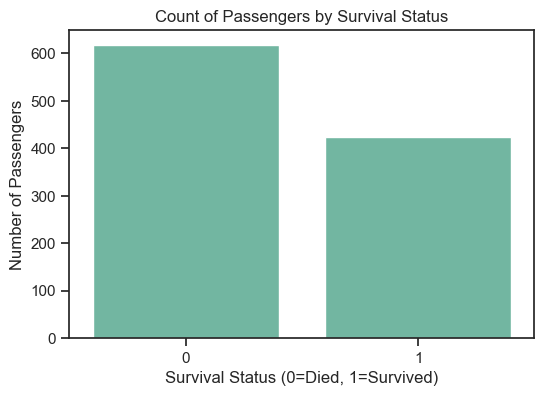

survived
0.0    0.59366
1.0    0.40634
Name: count, dtype: float64

In [3]:
# Base rate of survival
plt.figure(figsize=(6, 4))
sns.countplot(x='survived', data=df)
plt.title('Count of Passengers by Survival Status')
plt.xlabel('Survival Status (0=Died, 1=Survived)')
plt.ylabel('Number of Passengers')
plt.xticks([0, 1], ['0', '1']) # Explicitly set x-axis ticks to 0 and 1 with integer labels
plt.show()
plt.show()
df["survived"].value_counts() / df["survived"].count()

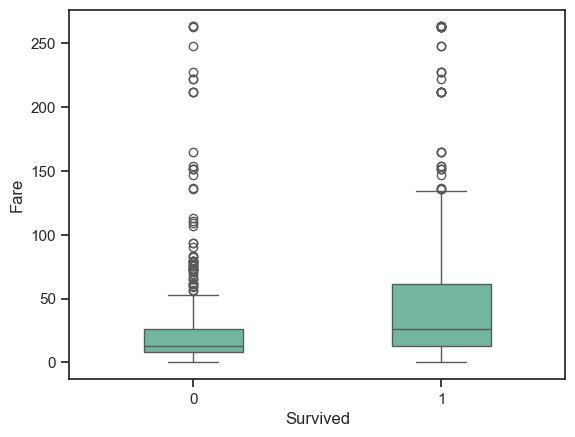

In [4]:
sns.boxplot(x = "survived", y = "fare", width = 0.4, data = df)
plt.xlabel("Survived")
plt.ylabel("Fare")
plt.xticks([0, 1], ["0", "1"])
plt.show()

Above we see boxplots that show the fare distribution grouped by our target variable (survival). The left boxplot corresponds to people that died and the right one to people that survived. Let's look at an alternative plot of the distribution of fare according to survival:

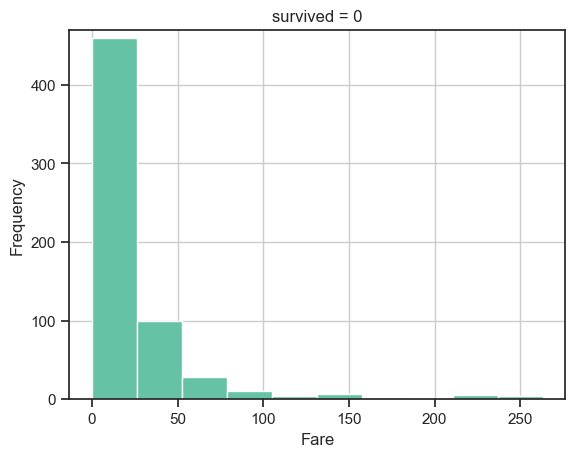

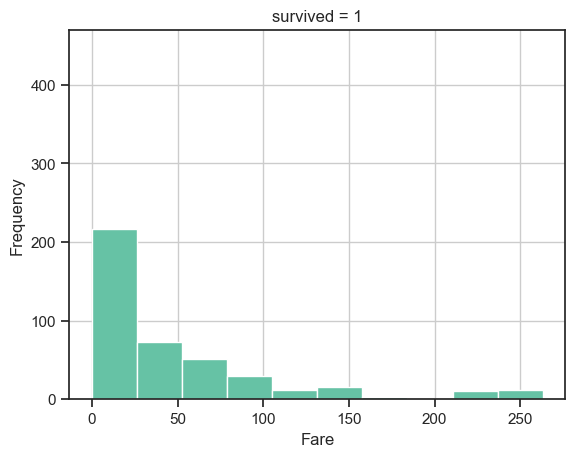

In [5]:
for r in range(2):
    hist = df[df.survived == r].hist("fare")
    plt.title("survived = " + str(r))
    plt.xlabel("Fare")
    plt.ylabel("Frequency")
    plt.ylim(0,470)
    plt.show()

We would use Fare to predict the survival. let's quantify the threshold = 50

In [6]:
# entropy funciton
def entropy(target_column):
    # get the counts of each target value
    target_counts = target_column.value_counts().astype(float).values
    total = target_column.count()
    # compute probas
    probas = target_counts / total
    # p_i * log_2 (p_i)
    entropy_components = probas * np.log2(probas)
    # return negative sum
    return - entropy_components.sum()

In [ ]:
# Information Gain
def information_gain(df, info_column, target_column, threshold):
    """ 
        computes H(target) - H(target | info > thresh) - H(target | info <= thresh)
    """
    #split data
    data_above_thresh = df[df[info_column] > threshold]    # it still has all the columns
    data_below_thresh = df[df[info_column] <= threshold]
    #get entropy
    H = entropy(df[target_column])
    entropy_above = entropy(data_above_thresh[target_column])
    entropy_below = entropy(data_below_thresh[target_column])
    #compute weighted average
    ct_above = data_above_thresh.shape[0]
    ct_below = data_below_thresh.shape[0]
    tot = float(df.shape[0])
    return H - entropy_above * ct_above / tot - entropy_below * ct_below / tot

In [10]:
threshold = 50
prior_entropy = entropy(df["survived"])
IG = information_gain(df, "fare", "survived", threshold)
print ("IG of %.4f using a threshold of %.2f given a prior entropy of %.4f" % (IG, threshold, prior_entropy))

IG of 0.0554 using a threshold of 50.00 given a prior entropy of 0.9745


How good was our guess of 50?

In [13]:
def best_threshold(df, infor_column, target_column, criteria = information_gain):
    max_ig= 0
    max_threshold = 0

    for thresh in df[infor_column].unique():
        IG = criteria(df, infor_column, target_column, thresh)
        if IG > max_ig:
            max_ig = IG
            max_threshold = thresh
    return (max_threshold, max_ig)

max_threshold, max_ig = best_threshold(df, "fare", "survived")
print ("the maximum IG we can achieve splitting on %s is %.4f using a thresh of %.2f" % ('fare', max_ig, max_threshold))

the maximum IG we can achieve splitting on fare is 0.0578 using a thresh of 52.00


If other features also give us strong clues about survival

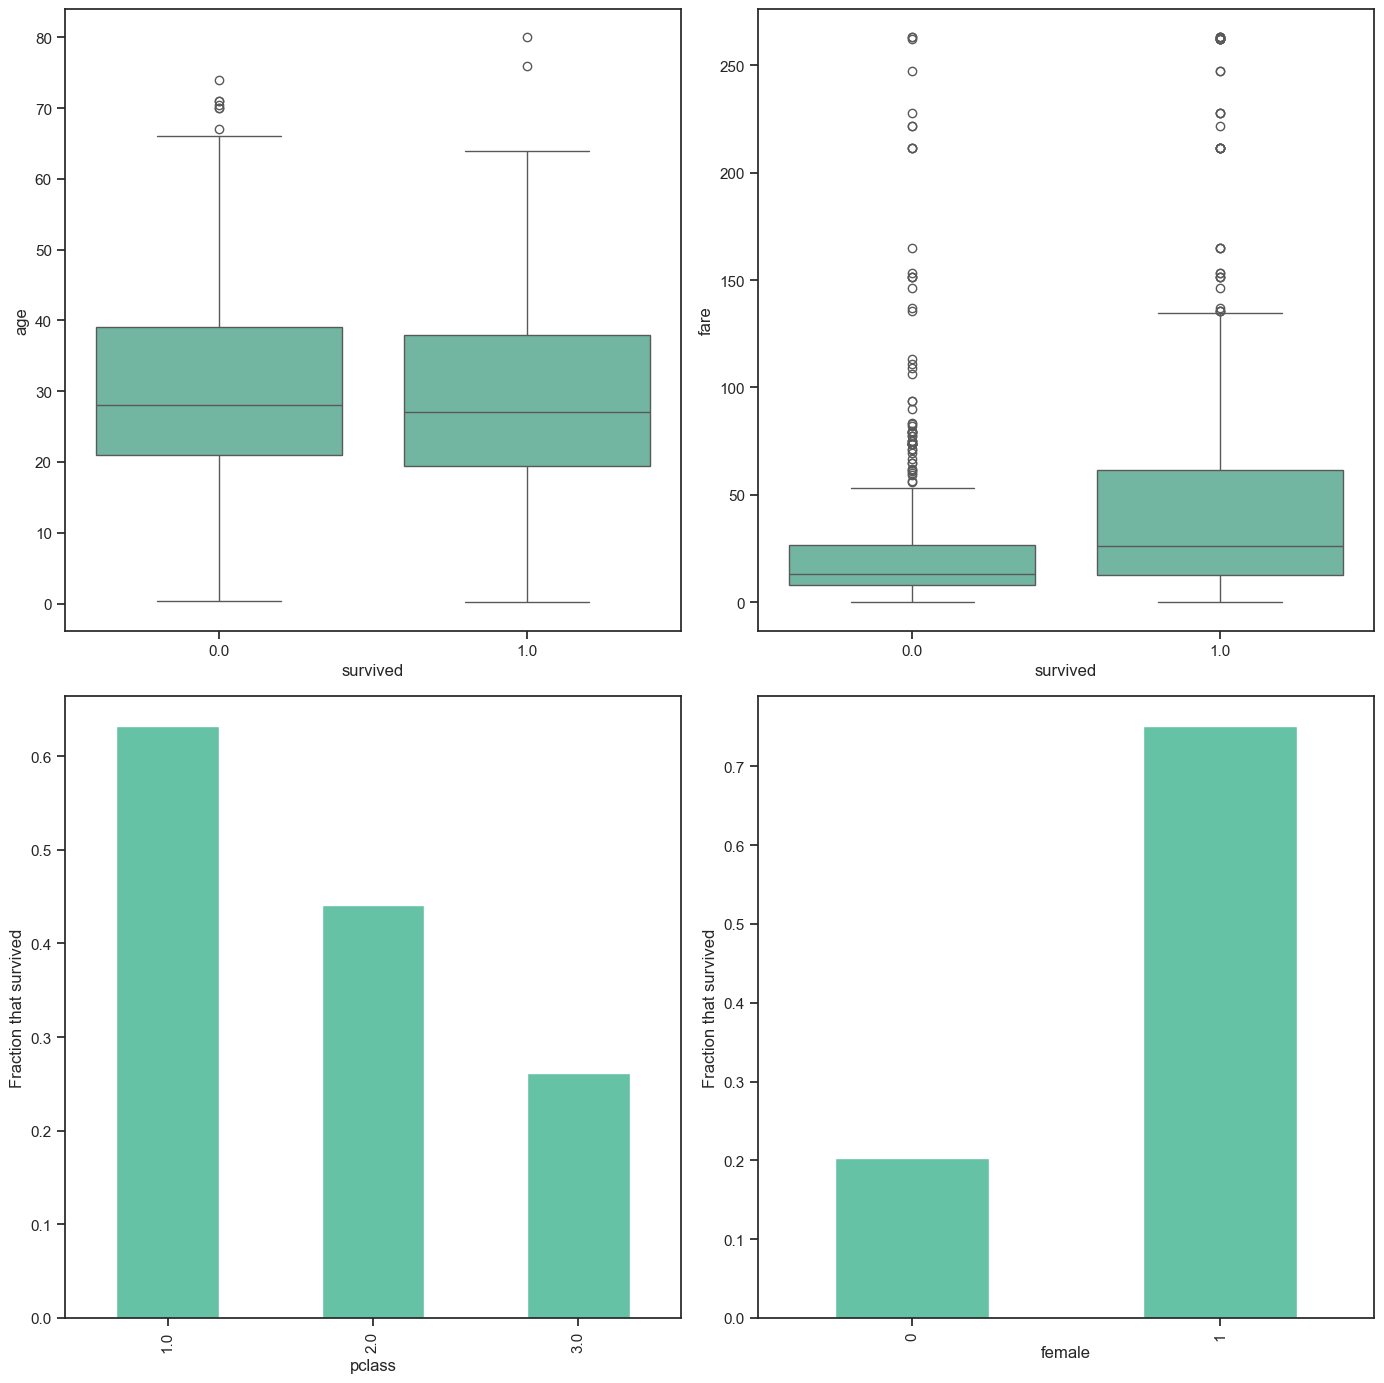

In [16]:
# Name of different columns
categorical_cols = ["pclass", "female"]
continuous_cols = ["age", "fare"]
target_col = "survived"
predictor_cols = categorical_cols + continuous_cols

# This is to plot everything in 2 by 2 space
rows, cols = 2, 2
fig, axs = plt.subplots(ncols=cols, nrows=rows, figsize=(7*cols, 7*rows))
axs = axs.flatten()
posn = 0

# Plot continuous features
for col in continuous_cols:
    sns.boxplot(x=target_col, y=col, data=df, ax=axs[posn])
    axs[posn].set_ylabel(col)
    axs[posn].set_title("")
    posn += 1

# Plot categorical features
for col in categorical_cols:
    df.groupby(col)[target_col].mean().plot(kind="bar", ax=axs[posn])
    axs[posn].set_ylabel("Fraction that survived")
    posn += 1

plt.tight_layout()

In [17]:
def best_split(df, info_columns, target_column, criteria=information_gain):
    maximum_ig = 0
    maximum_threshold = 0
    maximum_column = ""

    for info_column in info_columns:
        thresh, ig = best_threshold(df, info_column, target_column, criteria)

        if ig > maximum_ig:
            maximum_ig = ig
            maximum_threshold = thresh
            maximum_column = info_column

    return maximum_column, maximum_threshold, maximum_ig

max_col, max_threshold, max_ig = best_split(df, predictor_cols, "survived")

print ("The best column to split on is %s giving us a IG of %.4f using a thresh of %.2f" % (max_col, max_ig, max_threshold))

The best column to split on is female giving us a IG of 0.2164 using a thresh of 0.00


The Classification Tree: Recursive Splitting
Tree-structured models are one of the most popular and powerful sorts of machine learning algorithm.  They include classification or class-probability estimation trees (aka "decision trees"), regression trees, and many more complex models built by combining tree-structured models, such as random forests and gradient boosted models (which usually combine trees).

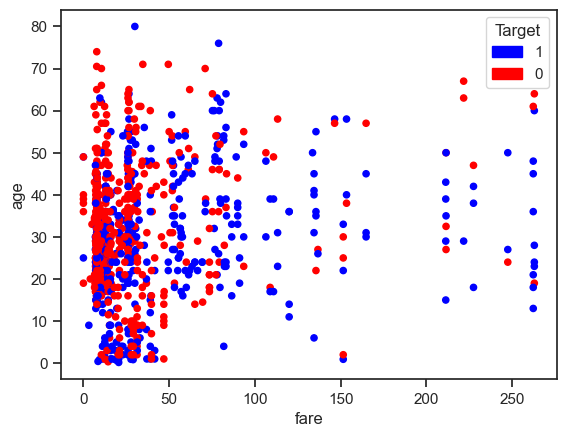

In [18]:
import matplotlib.patches as mpatches

cmap = {1: 'blue', 0: 'red'}
df.plot(kind="scatter", x="fare", y="age", c=[cmap[c] for c in df[target_col]])
plt.legend(handles=[mpatches.Patch(color=cmap[k], label=k) for k in cmap], loc=1, title="Target", frameon=True)
plt.show()

Let's use sklearn's implementation which includes some additiona functionality. 

In [19]:
from sklearn.tree import DecisionTreeClassifier
# Define the model (tree)
# ---> This is really both defining the model AND the ML algorithm to learn (train) it!
# choose tree max depth (there are better ways to limit complexity, but this is very understandable)
maxi_depth = 3
our_decision_tree = DecisionTreeClassifier(max_depth=maxi_depth, criterion= "entropy")    # Look at those 2 arguments !!!!
# Tell the model what is the "training" data and then train it
our_decision_tree.fit(df[predictor_cols], df["survived"])

,criterion,'entropy'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


Visualization of the results

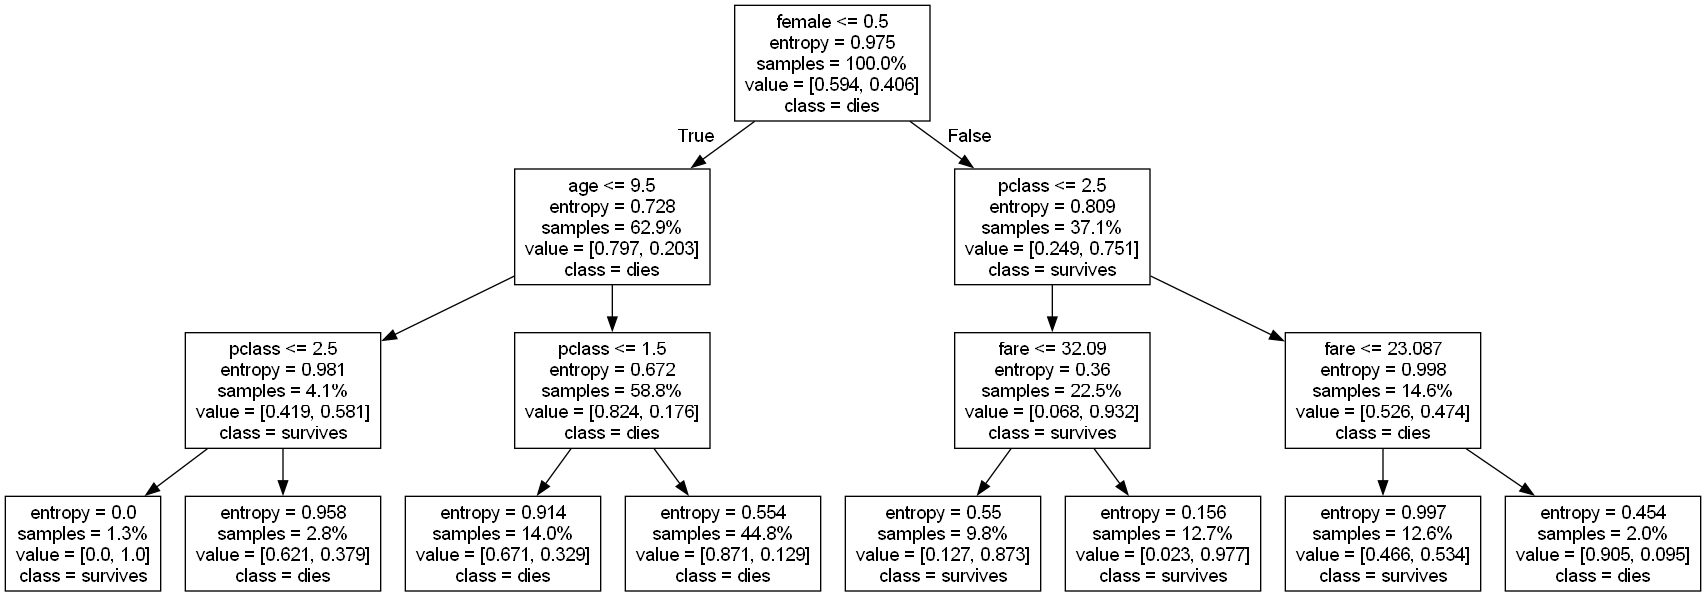

In [20]:
from IPython.display import Image
from sklearn.tree import export_graphviz
import shutil 
import subprocess

def visualize_tree(decision_tree, feature_names, class_names, directory = "./images", name = "our_tree", proportion = True):
    # export our decision tree to graphviz format
    dot_name = "%s/%s.dot" % (directory, name)
    dot_file = export_graphviz(decision_tree, out_file=dot_name, feature_names=feature_names,
                               class_names=class_names, proportion=proportion)
    # Call grphviz to make an image file from our decision tree
    image_name = "%s/%s.png" % (directory, name)
    if shutil.which("dot") is None:
        print("Graphviz 'dot' not found. Install Graphviz to render the tree image.")
        return None
    subprocess.run(["dot", "-T", "png", dot_name, "-o", image_name], check=True)
    # Return the .png image so we can see it
    return Image(filename=image_name)

visualize_tree(our_decision_tree, predictor_cols, ["dies", "survives"])

Let's look at `"age"` and `"fare"`, including the **DECISION SURFACE!!**

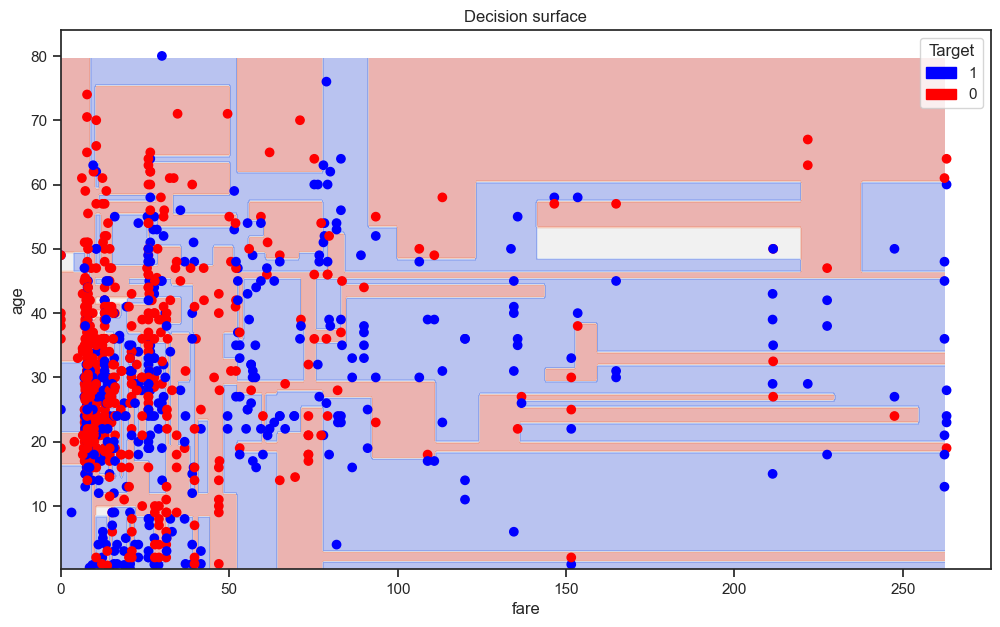

In [21]:
def Decision_Surface(data, col1, col2, target, model, probabilities=True):
    # Get bounds
    x_min, x_max = data[col1].min(), data[col1].max()
    y_min, y_max = data[col2].min(), data[col2].max()
    # Create a mesh
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.5), np.arange(y_min, y_max,0.5))
    meshed_data = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=[col1, col2])
    # Get predictions for the mesh
    tdf = data[[col1, col2]]
    model.fit(tdf, target)
    if probabilities:
        Z = model.predict_proba(meshed_data)[:, 1].reshape(xx.shape)
    else:
        Z = model.predict(meshed_data).reshape(xx.shape)
    # Chart details
    plt.figure(figsize=[12,7])
    plt.title("Decision surface")
    plt.xlabel(col1)
    plt.ylabel(col2)
    if probabilities:
        # Color-scale on the contour (surface = separator)
        cs = plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm_r, alpha=0.4)
    else:
        # Only a curve/line on the contour (surface = separator)
        cs = plt.contourf(xx, yy, Z, levels=[-1,0,1], cmap=plt.cm.coolwarm_r, alpha=0.4)
    # Plot scatter plot
    cmap = {1: 'blue', 0: 'red'}
    colors = [cmap[int(c)] for c in target]
    plt.scatter(data[col1], data[col2], color=colors)
    # Build legend
    plt.legend(handles=[mpatches.Patch(color=cmap[k], label=k) for k in cmap], loc="best", title="Target", frameon=True)
    plt.show()

#tree_depth=maxi_depth
tree_depth=20
viz_model = DecisionTreeClassifier(max_depth=tree_depth, criterion="entropy")
Decision_Surface(df, "fare", "age", df.survived, viz_model)
visualize_tree(viz_model, ["fare","age"], ["dies", "survives"])


How good is our model? Let us compute accuracy which is the percent of times where we correctly identified whether a passenger survives. (*Note:* This **confounds model quality and decision logic**. A single training-set accuracy mixes (1) how well the model learns patterns and (2) how predictions are turned into decisions (for example, threshold and metric choice).)

**Important:** The accuracy below is computed on the same data used to train the model (the training set), so it is usually too optimistic.In practice, we should evaluate on a separate **test set** (or use cross-validation), and use additional metrics when decision costs differ.

In [22]:
from sklearn import metrics
print ( "Accuracy = %.3f" % (metrics.accuracy_score(our_decision_tree.predict(df[predictor_cols]), df["survived"])) )

Accuracy = 0.810


What are some other ways we could classify the data? The other bread-and-butter machine learning method is equation fitting, the most common instance being linear modeling; let's take a look to see how linear modeling partitions the data.

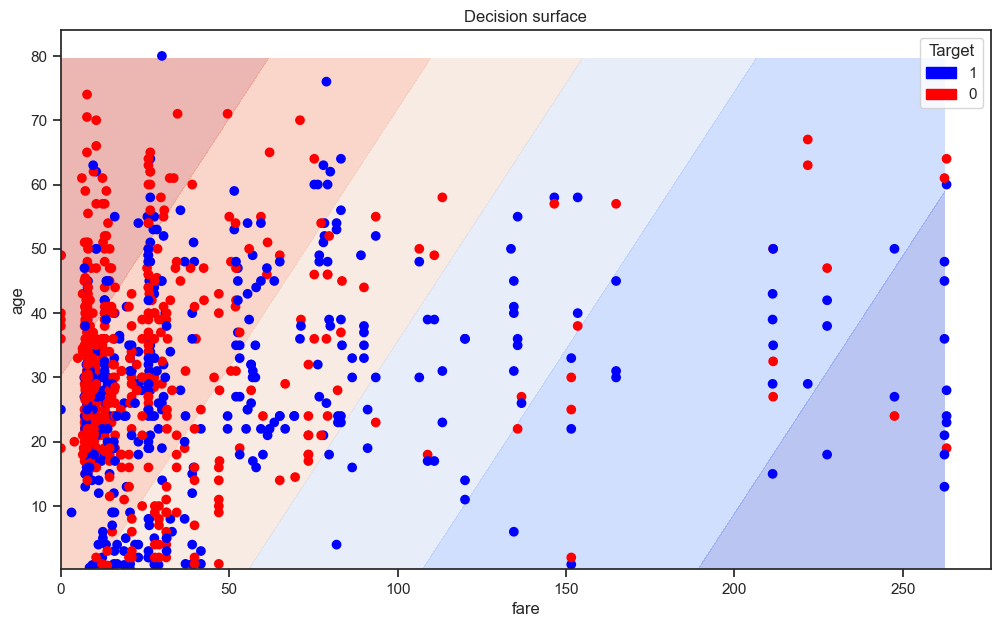

In [23]:
from sklearn import linear_model

our_lin_model = linear_model.LogisticRegression(max_iter=1000)
Decision_Surface(df, "fare", "age", df.survived, our_lin_model, True)

In [24]:
from sklearn import metrics
our_lin_model.fit(df[predictor_cols], df.survived)
print ("Accuracy = %.3f" % (metrics.accuracy_score(our_lin_model.predict(df[predictor_cols]), df.survived)) )

Accuracy = 0.792
